# Experiment 3: Random vs SVD Initialisation

Compare PALM, iPALM, and FISTA-PALM using different initialisations.

**Setup**
- Matrix: $A \in \mathbb{R}^{100 \times 80}$, rank $r = 10$
- Sparsity levels in $Y$: $10\%$, $25\%$, $33\%$
- Initialisations:
  - Random nonnegative
  - SVD-based
- Iterations: $100$

**Goal**

Evaluate how initialisation affects convergence behaviour and final objective values.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import generate_low_rank_matrix_problem, svd_initialisation
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_random_vs_svd
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

m, n, r = 100, 80, 10
sparsity_levels = [0.10, 0.25, 0.33]
max_iter = 100
gamma = 1.2

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "iPALM": IPALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

## Run solvers

Compare convergence from random and SVD initialisations.

In [3]:
plot_data = {}
records = {}

A, X0_random, Y0_random, _, _ = generate_low_rank_matrix_problem(
    m, n, r, sparsity=0.25, seed=42
)

X0_svd, Y0_svd = svd_initialisation(A, r)

for sparsity in sparsity_levels:
    sparsity_label = f"{int(sparsity * 100)}%"
    plot_data[sparsity_label] = {}

    problem = make_matrix_factorisation_problem(A, r, sparsity, gamma=gamma)

    initialisations = {
        "Random": (X0_random, Y0_random),
        "SVD": (X0_svd, Y0_svd),
    }

    for init_name, (X0, Y0) in initialisations.items():
        plot_data[sparsity_label][init_name] = {}

        for method_name, solver in solvers.items():
            _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())

            plot_data[sparsity_label][init_name][method_name] = hist

            records.setdefault("Sparsity", []).append(sparsity_label)
            records.setdefault("Initialisation", []).append(init_name)
            records.setdefault("Method", []).append(method_name)
            records.setdefault("Final Objective", []).append(hist[-1])
            records.setdefault("Iterations", []).append(len(hist) - 1)

## Convergence comparison

Objective vs iteration (log scale) for each sparsity level and initialisation.

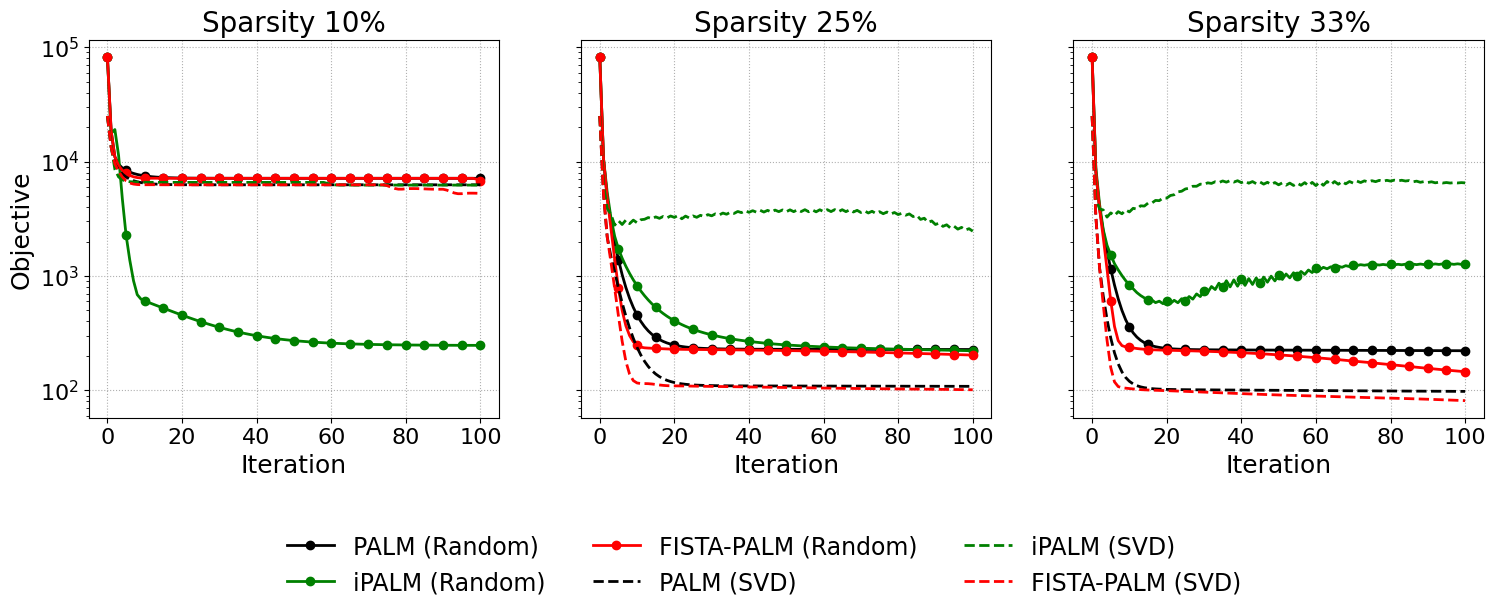

In [4]:
params = {
    "m": m,
    "n": n,
    "r": r,
    "slevels": len(sparsity_levels),
    "iter": max_iter,
}

plot_random_vs_svd(
    plot_data,
    sparsity_levels,
    save_path=make_fig_path(ROOT, "random_vs_svd", params),
)

## Final objective comparison

Final objective values and iterations for each method and initialisation.

In [5]:
df = pd.DataFrame(records)

save_table(
    df,
    ROOT,
    "random_vs_svd_summary",
    params,
)

df

,Sparsity,Initialisation,Method,Final Objective,Iterations
0,10%,Random,PALM,7135.108553,100
1,10%,Random,iPALM,247.291401,100
2,10%,Random,FISTA-PALM,6792.019716,100
3,10%,SVD,PALM,6260.659954,100
4,10%,SVD,iPALM,6224.236952,100
5,10%,SVD,FISTA-PALM,5269.590637,100
6,25%,Random,PALM,227.484904,100
7,25%,Random,iPALM,221.940990,100
8,25%,Random,FISTA-PALM,203.414124,100
9,25%,SVD,PALM,108.427024,100


## Observations

- SVD initialisation has a strong but method-dependent effect on performance.
- For PALM and FISTA-PALM, SVD generally improves the final objective, especially at higher sparsity levels.
- For iPALM, SVD initialisation often degrades performance significantly and can lead to unstable behaviour.
- At low sparsity (10%), random initialisation performs better across all methods.
- At higher sparsity levels (25%–33%), FISTA-PALM with SVD achieves the best overall objective values.